<a href="https://colab.research.google.com/github/juanalytics/computacion-visual/blob/main/2025-10-01_taller_2_cv_3d/ejercicios/10_modelos_color_percepcion/Ejercicio_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎨 Ejercicio 10 — Explorando el Color (RGB, HSV, CIE Lab + Simulaciones)

Este notebook permite:
- Convertir imágenes entre espacios de color **RGB, HSV y CIE Lab**.
- Visualizar los **canales individuales** de cada modelo.
- Simular **daltonismo** (protanopía, deuteranopía y tritanopía).
- Simular condiciones de **baja iluminación**.
- Aplicar filtros: **temperatura de color (cálido/frío)**, **inversión** y **monocromo**.
- Usar la función `switch_model` para alternar fácilmente entre modelos y transformaciones.


## 🔧 1. Instalación de dependencias


In [ ]:
!pip install scikit-image colorspacious


## 📚 2. Importación de librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color

# Intentamos cargar colorspacious
try:
    import colorspacious
    COLORSACIOUS_AVAILABLE = True
except Exception:
    COLORSACIOUS_AVAILABLE = False


## 🖼️ 3. Cargar imagen de ejemplo
Usaremos la imagen `astronauta` incluida en **skimage**.

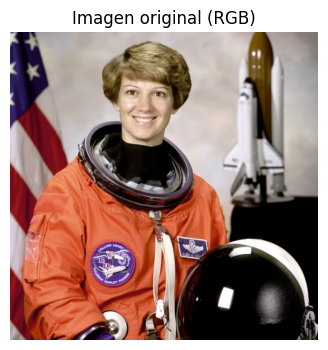

In [ ]:
img_rgb = img_as_float(data.astronaut())

plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Imagen original (RGB)")
plt.show()

## 🔄 4. Conversiones entre espacios de color

In [ ]:
def rgb_to_hsv(img):
    return color.rgb2hsv(img)

def rgb_to_lab(img):
    return color.rgb2lab(img)

def lab_to_rgb(lab):
    return np.clip(color.lab2rgb(lab), 0, 1)


## 👁️ 5. Visualización de canales

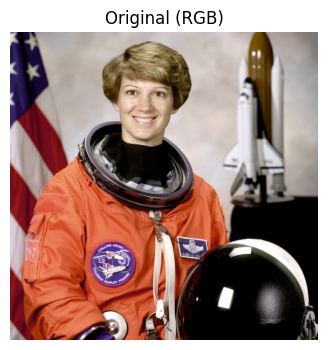

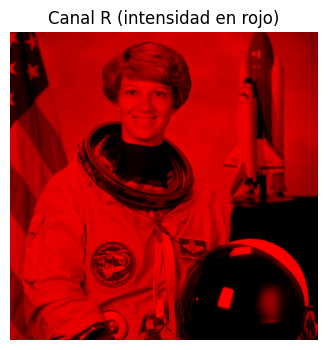

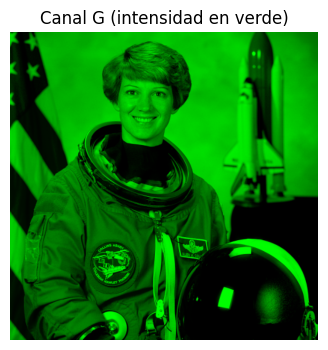

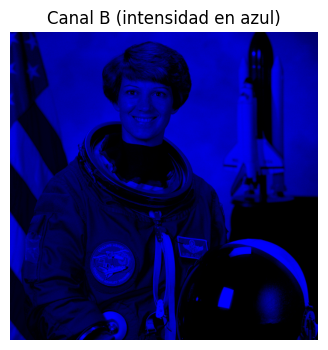

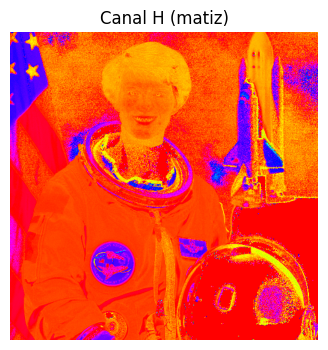

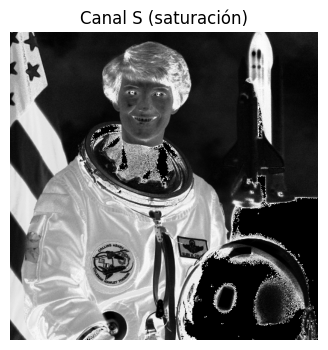

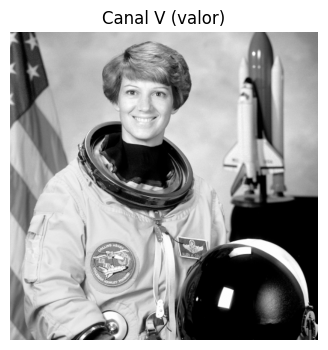

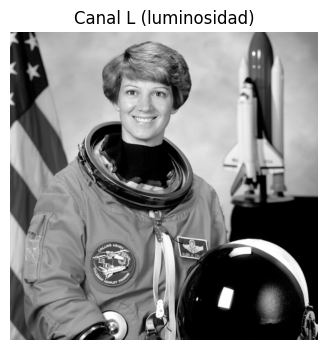

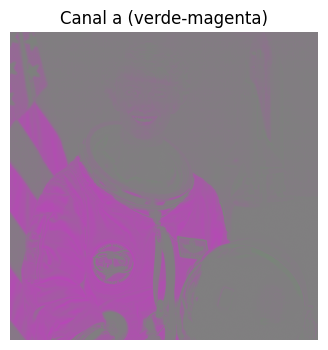

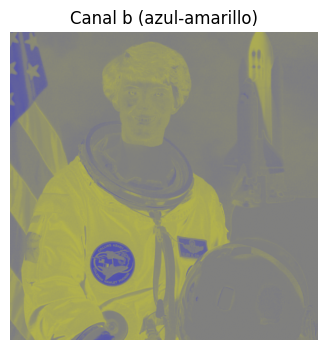

In [ ]:
def show_channels_rgb(img):
    r, g, b = img[...,0], img[...,1], img[...,2]
    show_image("Original (RGB)", img)
    show_image("Canal R (intensidad en rojo)", np.stack([r, np.zeros_like(r), np.zeros_like(r)], axis=-1))
    show_image("Canal G (intensidad en verde)", np.stack([np.zeros_like(g), g, np.zeros_like(g)], axis=-1))
    show_image("Canal B (intensidad en azul)", np.stack([np.zeros_like(b), np.zeros_like(b), b], axis=-1))

def show_channels_hsv(img):
    hsv = rgb_to_hsv(img)
    h, s, v = hsv[...,0], hsv[...,1], hsv[...,2]
    # Hue → convertido a RGB
    hue_rgb = color.hsv2rgb(np.stack([h, np.ones_like(h), np.ones_like(h)], axis=-1))
    show_image("Canal H (matiz)", hue_rgb)
    # Saturación y Valor en grises
    show_image("Canal S (saturación)", np.stack([s,s,s], axis=-1))
    show_image("Canal V (valor)", np.stack([v,v,v], axis=-1))

def show_channels_lab(img):
    lab = rgb_to_lab(img)
    L = lab[...,0]/100.0
    a = lab[...,1]
    b = lab[...,2]
    # Luminancia → grises
    show_image("Canal L (luminosidad)", np.stack([L,L,L], axis=-1))
    # a → verde (-) a magenta (+)
    a_norm = (a + 128) / 255.0
    show_image("Canal a (verde-magenta)", np.stack([a_norm, 1-a_norm, a_norm], axis=-1))
    # b → azul (-) a amarillo (+)
    b_norm = (b + 128) / 255.0
    show_image("Canal b (azul-amarillo)", np.stack([b_norm, b_norm, 1-b_norm], axis=-1))

# Mostrar ejemplos
show_channels_rgb(img_rgb)
show_channels_hsv(img_rgb)
show_channels_lab(img_rgb)


## 🌈 6. Simulación de Daltonismo


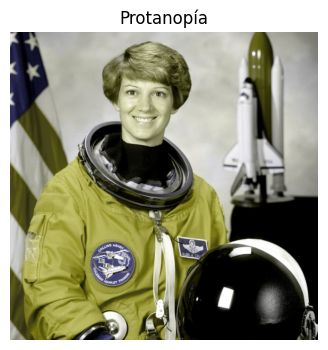

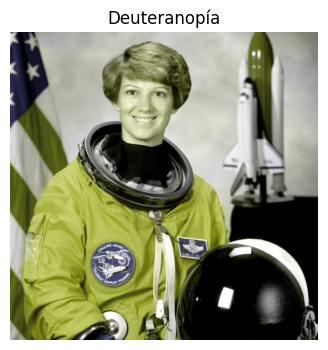

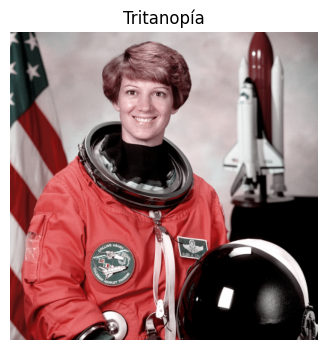

In [ ]:
# Matrices aproximadas
PROTANOPIA_MAT = np.array([[0.567,0.433,0],
                           [0.558,0.442,0],
                           [0,0.242,0.758]])
DEUTERANOPIA_MAT = np.array([[0.625,0.375,0],
                             [0.7,0.3,0],
                             [0,0.3,0.7]])
TRITANOPIA_MAT = np.array([[0.95,0.05,0],
                           [0,0.433,0.567],
                           [0,0.475,0.525]])

def apply_linear_matrix(img, M):
    h,w,_ = img.shape
    flat = img.reshape(-1,3)
    transformed = np.dot(flat, M.T).reshape(h,w,3)
    return np.clip(transformed,0,1)

def simulate_cvd(img, mode='protanopia'):
    if COLORSACIOUS_AVAILABLE:
        param = {'cvd_type': mode.replace('opia',''), 'severity': 1.0}
        try:
            return np.clip(colorspacious.cspace_convert(img, "sRGB1", ("sRGB1+CVD", param)), 0, 1)
        except:
            pass
    M = {'protanopia': PROTANOPIA_MAT,
         'deuteranopia': DEUTERANOPIA_MAT,
         'tritanopia': TRITANOPIA_MAT}[mode]
    return apply_linear_matrix(img, M)

# Mostrar simulaciones
show_image("Protanopía", simulate_cvd(img_rgb,'protanopia'))
show_image("Deuteranopía", simulate_cvd(img_rgb,'deuteranopia'))
show_image("Tritanopía", simulate_cvd(img_rgb,'tritanopia'))


## 💡 7. Ajuste de brillo y contraste


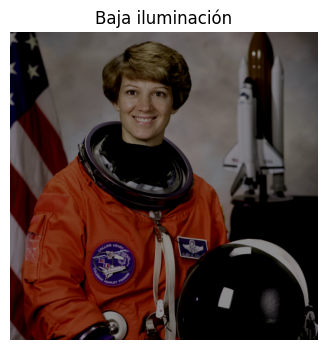

In [ ]:
def adjust_brightness_contrast(img, brightness=0.0, contrast=1.0):
    out = contrast*(img-0.5)+0.5+brightness
    return np.clip(out,0,1)

show_image("Baja iluminación", adjust_brightness_contrast(img_rgb,-0.3,0.7))


## 🎛️ 8. Filtros de color


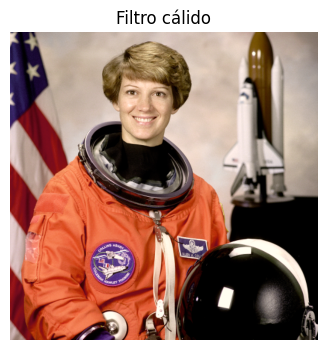

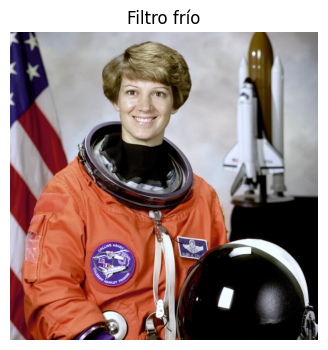

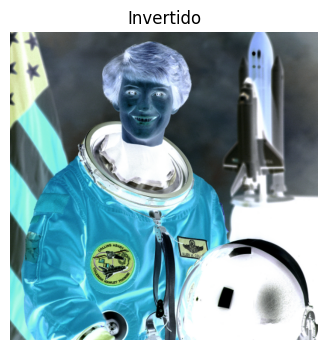

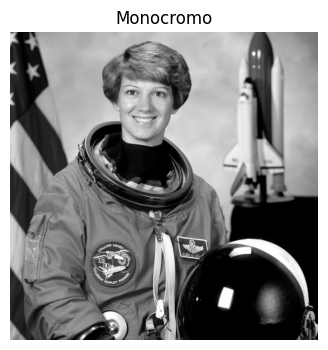

In [ ]:
def color_temperature_filter(img, kelvin_shift=0):
    factor = np.clip(1.0 + kelvin_shift/10000.0, 0.5, 1.5)
    r_factor = 1.0 + 0.25*(factor-1.0)
    b_factor = 1.0 - 0.25*(factor-1.0)
    out = img.copy()
    out[...,0] = np.clip(out[...,0]*r_factor,0,1)
    out[...,2] = np.clip(out[...,2]*b_factor,0,1)
    return out

def invert_image(img):
    return 1.0 - img

def monochrome(img):
    gray = 0.21*img[...,0]+0.72*img[...,1]+0.07*img[...,2]
    return np.stack([gray,gray,gray],axis=-1)

# Ejemplos
show_image("Filtro cálido", color_temperature_filter(img_rgb,2000))
show_image("Filtro frío", color_temperature_filter(img_rgb,-2000))
show_image("Invertido", invert_image(img_rgb))
show_image("Monocromo", monochrome(img_rgb))


## 🔀 9. Función `switch_model`


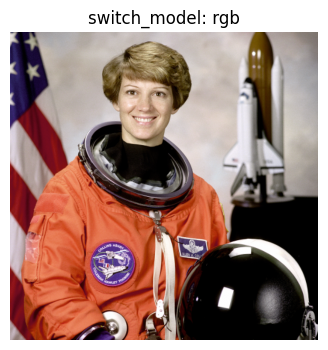

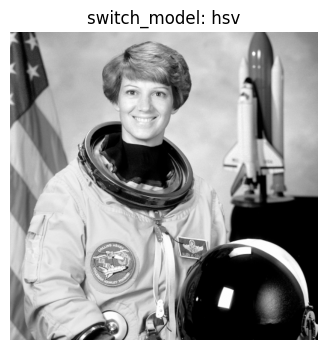

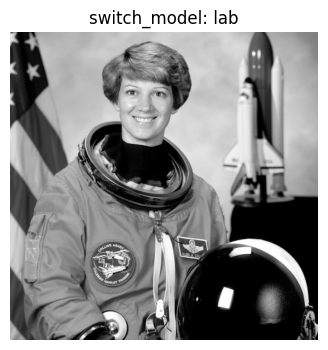

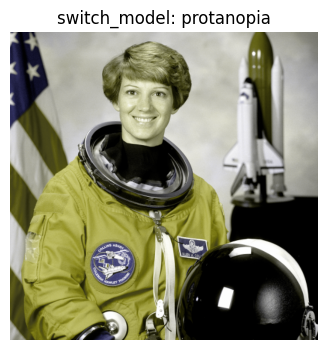

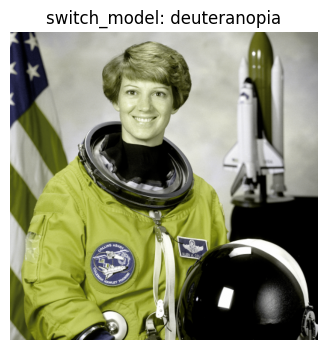

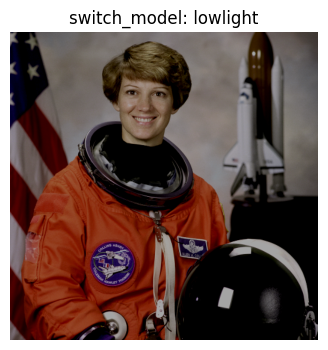

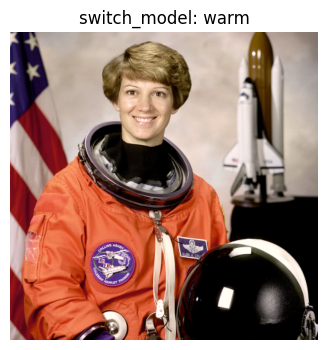

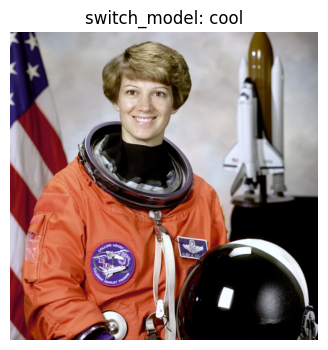

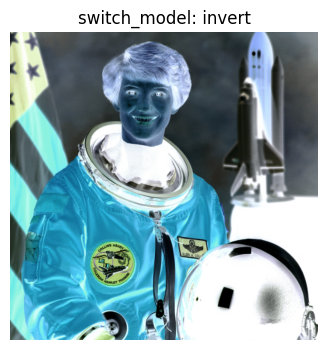

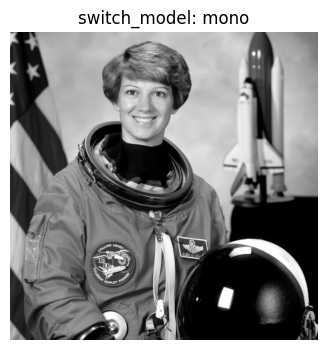

In [ ]:
def switch_model(img, model='rgb'):
    m = model.lower()
    if m=='rgb': return img
    elif m=='hsv': return np.stack([rgb_to_hsv(img)[...,2]]*3,axis=-1)
    elif m=='lab': return np.stack([rgb_to_lab(img)[...,0]/100]*3,axis=-1)
    elif m in ('protanopia','deuteranopia','tritanopia'): return simulate_cvd(img,m)
    elif m=='lowlight': return adjust_brightness_contrast(img,-0.25,0.8)
    elif m=='warm': return color_temperature_filter(img,1500)
    elif m=='cool': return color_temperature_filter(img,-1500)
    elif m=='invert': return invert_image(img)
    elif m=='mono': return monochrome(img)
    else: raise ValueError("Modelo no soportado")

# Demostración
for m in ['rgb','hsv','lab','protanopia','deuteranopia','lowlight','warm','cool','invert','mono']:
    show_image(f"switch_model: {m}", switch_model(img_rgb,m))


## 📑 10. Comparativas y Reflexión

En esta sección se presentan algunas comparativas entre los canales y las simulaciones aplicadas a la imagen.  

### 🔹 Comparativas de canales
- **RGB**: cada canal muestra la intensidad de rojo, verde o azul que compone la imagen original. Visualmente, esto ayuda a entender cómo la mezcla de intensidades da lugar al color final.  
- **HSV**: el canal **H** refleja la información del matiz (los colores básicos), mientras que **S** y **V** controlan saturación e intensidad. Aquí se entiende mejor por qué la saturación es clave para colores vivos y cómo el valor afecta la claridad de la imagen.  
- **Lab**: el canal **L** representa la luminosidad percibida. Los canales **a** y **b** revelan cómo el ojo humano separa la información cromática en ejes oponentes (verde–magenta y azul–amarillo).  

### 🔹 Simulaciones de visión
- **Daltonismo (protanopía, deuteranopía, tritanopía)**: se observa cómo desaparecen o se confunden ciertas gamas de color, lo que demuestra la importancia de diseñar interfaces y gráficos accesibles para personas con deficiencias visuales.  
- **Baja iluminación**: la imagen se torna opaca y con menor contraste, simulando condiciones de visibilidad reducida.  
- **Filtros (cálido, frío, invertido, monocromo)**: muestran cómo se puede manipular la percepción del color con simples ajustes, generando diferentes ambientes o estilos.  

### 📝 Reflexión
Este ejercicio permite comprender que:
- El color no es solo un valor numérico, sino una **percepción dependiente del modelo y del observador**.  
- Los modelos **RGB, HSV y Lab** aportan perspectivas complementarias sobre la misma información visual.  
- Simulaciones como el daltonismo o la baja iluminación evidencian la necesidad de **diseños inclusivos y adaptativos** en sistemas gráficos y de información.  
- Explorar diferentes canales y transformaciones ayuda a **entrenar la intuición** sobre cómo la máquina procesa el color frente a cómo lo percibimos los humanos.  
